## 1. S - Sample (Amostragem)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Carregamento
df = pd.read_csv('abt_churn.csv')

# --- CORREÇÃO DOS NOMES DAS COLUNAS ---
date_col = 'dtRef'
id_col = 'idUsuario'
target = 'flagChurn'

# Garantir que a coluna de data esteja no formato correto
df[date_col] = pd.to_datetime(df[date_col])

# Ordenar por data para separar o OOT (último mês disponível)
df = df.sort_values(date_col)
last_month = df[date_col].max()

df_oot = df[df[date_col] == last_month].copy()
df_dev = df[df[date_col] < last_month].copy()

# Train/Test Split (80/20)
X = df_dev.drop(columns=[target, id_col, date_col])
y = df_dev[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Base OOT (Mês de referência): {last_month}")
print(f"Proporção Churn Treino: {y_train.mean():.2%}")
print(f"Proporção Churn Teste:  {y_test.mean():.2%}")
print(f"Proporção Churn OOT:    {df_oot[target].mean():.2%}")

Base OOT (Mês de referência): 2025-04-01 00:00:00
Proporção Churn Treino: 46.89%
Proporção Churn Teste:  46.87%
Proporção Churn OOT:    50.50%


## 2. E - Explore (Exploração)


Variáveis com Nulos:
 Series([], dtype: float64)


qtdeTransacoes          qtdeDias        mediaTransacoesDias            \
                 mean median       mean median                mean    median   
target                                                                         
0          295.784678   50.0  28.983228   13.0            6.176668  3.618615   
1           50.431725    9.0   9.281828    3.0            3.953271  2.234375   

        saldoPontos        qtdePontosPos         
               mean median          mean median  
target                                           
0       1402.307797  559.5   2932.094288  689.0  
1        444.286961  120.5    664.115503  124.0

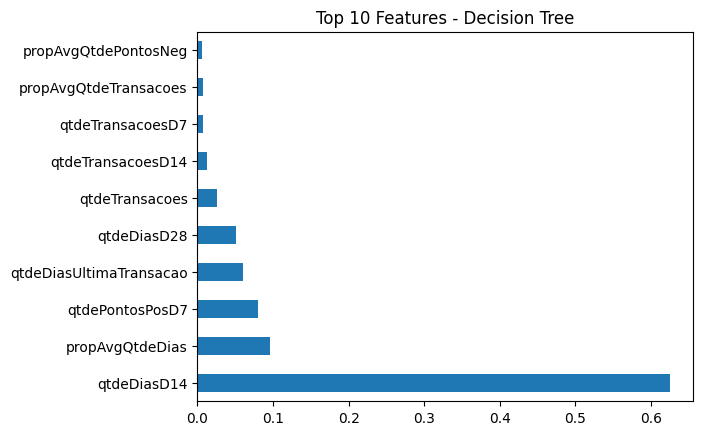

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# 1. Nulos
null_summary = X_train.isnull().mean()
print("Variáveis com Nulos:\n", null_summary[null_summary > 0])
# Estratégia: Preencheremos com a mediana (numéricas) e 'Unknown' (categóricas) no Pipeline.

# 2. Análise Bivariada (Exemplo para variáveis numéricas)
num_cols = X_train.select_dtypes(include=[np.number]).columns[:5] # Selecionando 5 primeiras
df_temp = X_train[num_cols].copy()
df_temp['target'] = y_train

summary_bivariada = df_temp.groupby('target').agg(['mean', 'median'])
display(summary_bivariada)

# 3. Feature Importance com Árvore Simples
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
# Preenchimento temporário apenas para o plot de importância
tree_clf.fit(X_train.fillna(-999).select_dtypes(include=[np.number]), y_train)

importances = pd.Series(tree_clf.feature_importances_, index=tree_clf.feature_names_in_)
importances.nlargest(10).plot(kind='barh', title='Top 10 Features - Decision Tree')
plt.show()


## 3. M - Modify (Modificação)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer

# Identificação de colunas
num_vars = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_vars = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Transformer Numérico: Imputação + Discretização (Binning)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('binning', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'))
])

# Transformer Categórico: Imputação + OneHot
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_vars),
    ('cat', cat_transformer, cat_vars)
])

## 4. M - Model (Modelagem)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Pipeline Completo
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Hiperparâmetros para busca
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__class_weight': ['balanced', 'balanced_subsample', None]
}

random_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_dist,
    n_iter=20, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

print(f"Melhores Parâmetros: {random_search.best_params_}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 11 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 12 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:3

Melhores Parâmetros: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__max_depth': 5, 'classifier__class_weight': None}


## 5. A - Assess (Avaliação)

Treino AUC: 0.8334
Teste AUC: 0.8281
OOT AUC: 0.8441


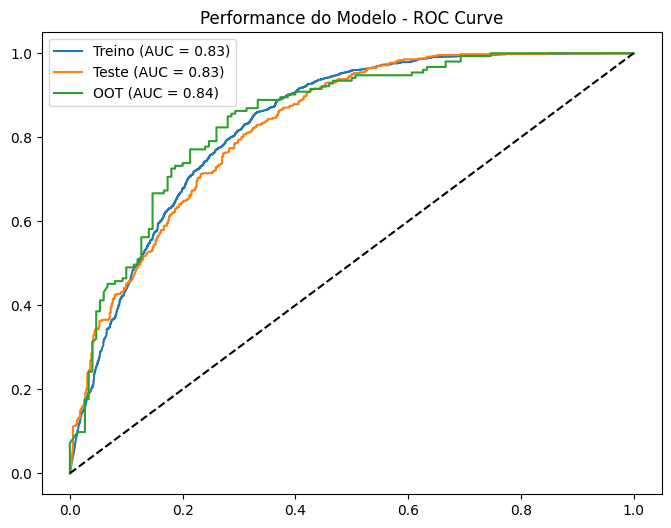


--- Ganhos Acumulados por Decil ---
decil
1    0.002053
2    0.010267
3    0.061602
Name: target, dtype: float64


In [15]:
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
import pickle

# Preparar dados OOT para avaliação
X_oot = df_oot.drop(columns=[target, id_col, date_col])
y_oot = df_oot[target]

sets = [(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste'), (X_oot, y_oot, 'OOT')]

plt.figure(figsize=(8,6))
for X_s, y_s, name in sets:
    probs = best_model.predict_proba(X_s)[:, 1]
    auc = roc_auc_score(y_s, probs)
    print(f"{name} AUC: {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_s, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.title('Performance do Modelo - ROC Curve')
plt.show()

# Lift nos decis (Base Teste)
probs_test = best_model.predict_proba(X_test)[:, 1]
results = pd.DataFrame({'prob': probs_test, 'target': y_test})
results = results.sort_values('prob', ascending=False).reset_index(drop=True)
results['decil'] = pd.qcut(results['prob'], q=10, labels=False, duplicates='drop') + 1
results = results.sort_values('decil')

lift = results.groupby('decil')['target'].sum() / y_test.sum()
print("\n--- Ganhos Acumulados por Decil ---")
print(lift.sort_index().cumsum().head(3)) # Mostra 10%, 20% e 30%

# Salvar
with open('modelo_churn_final.pkl', 'wb') as f:
    pickle.dump(best_model, f)